# Loppuprojekti  

## Auton rekisterikilven ja rekisterinumeron tunnistus yhdistetyllä YOLO- ja OCR-mallilla

Samuli Lamminmäki, Ismet Ymeri, Stefanos Thomas, Onni Luova, Jan Nässling

Tämä projekti keskittyy rekisterikilpien tunnistamiseen ja niiden sisältämän tekstin automaattiseen lukemiseen syötetyistä kuvista. Järjestelmä koostuu kahdesta vaiheesta: ensin YOLO-pohjainen objektintunnistusmalli paikantaa rekisterikilven kuvasta, minkä jälkeen räätälöity OCR-malli tulkitsee kilvessä olevat numerot ja kirjaimet.

## 1. Rekisterikilven tunnistus kuvasta
Rekisterikilven tunnistamiseen koulutamme valmiin YOLO-mallin, joka on suunniteltu paikallistamaan objektit kuvassa. Koulutusdata koostuu autoista ja niiden rekisterikilvistä eri ympäristöissä. Datasetin objektit on labeloitu käyttäen YOLO:n tavanomaisia normalisoituja koordinaatteja, jotka määrittävät rekisterikilven sijainnin ja koon kuvassa.

Linkki datasettiin: [https://universe.roboflow.com/roboflow-universe-projects/license-plate-recognition-rxg4e/dataset/11](https://universe.roboflow.com/roboflow-universe-projects/license-plate-recognition-rxg4e/dataset/11)

Datasetti sisältää 10125 kuvaa, jotka on valmiiksi jaettu: 70% koulutus-, 20% validointi- ja 10% testidataan.

Katsotaan seuraavaksi miltä treenidata näyttää.

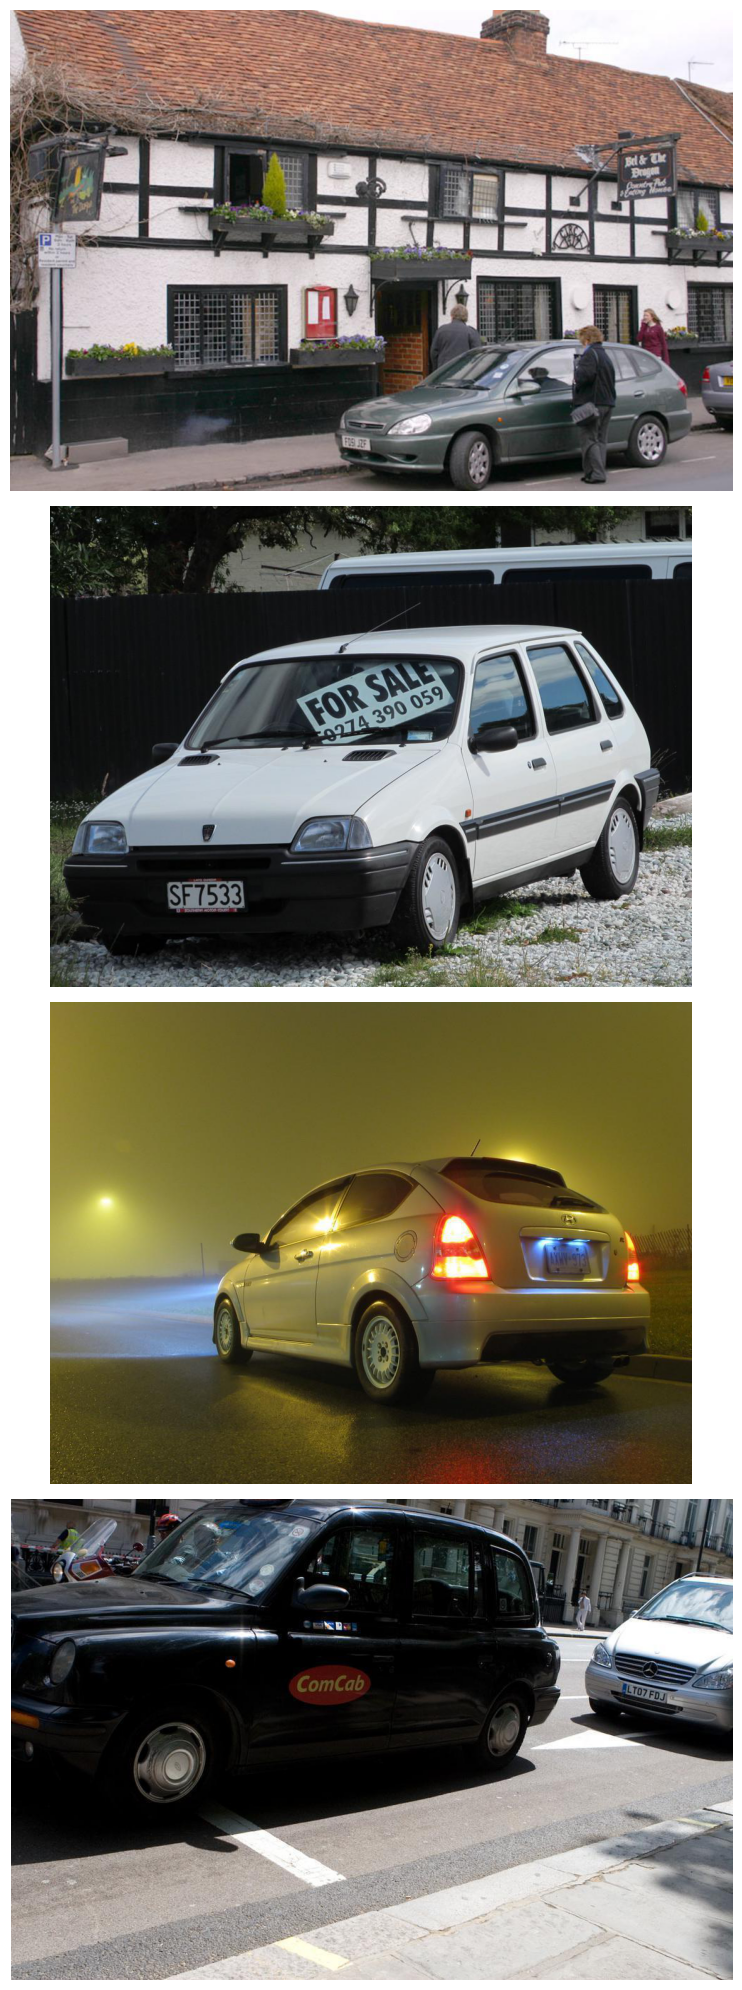

In [18]:
import os
import matplotlib.pyplot as plt
from PIL import Image

img_dir = "../../projects/datasets/licenseplate/train/images/"
img_files = [f for f in os.listdir(img_dir)]
img_paths = [os.path.join(img_dir, img_files[i]) for i in range(4)]
fig, axes = plt.subplots(4, 1, figsize=(10, 20))

for i, ax in enumerate(axes):
    img = Image.open(img_paths[i])
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

Kuten näemme, kuvat ovat kohtuullisen hyvälaatuisia ja monipuolisia, joten data soveltuu tehtävään mainiosti. Seuraavaksi ladataan jo koulutettu malli, tai jos mallia ei ole vielä koulutettu, suoritetaan sen koulutus. Malli koulutetaan vain viiden epookin ajan, koska sen kouluttaminen on melko raskasta.

Plots=True parametrin avulla saadaan koulutuksen aikana piirrettyä graafit, jotka kuvaavat mallin oppimista.

In [19]:
import os
from ultralytics import YOLO

# Jos malli on jo koulutettu, ladataan se
model_path = "runs/detect/license-plate-detector/weights/best.pt"

if os.path.exists(model_path):
    model = YOLO(model_path)
else:
    model = YOLO("yolov8n.pt")

    model.train(
        data="/mnt/c/Users/samul/PycharmProjects/NeuralNetworksProj/projects/datasets/licenseplate/data.yaml",
        epochs=5,
        imgsz=640,
        batch=30,
        name="license-plate-detector",
        workers=0,
        plots=True,
        verbose=False
    )

Testataan mallia muutamalla testikuvalla ja tarkastellaan mallin suorituskykyä.

image 1/1 /mnt/c/Users/samul/PycharmProjects/NeuralNetworksProj/projects/licenseplatedetector/../../projects/datasets/licenseplate/test/images/0002a5b67e5f0909_jpg.rf.c8f81ef986e3e99af6f349c200080453.jpg: 480x640 2 License_Plates, 17.8ms
Speed: 5.9ms preprocess, 17.8ms inference, 12.2ms postprocess per image at shape (1, 3, 480, 640)


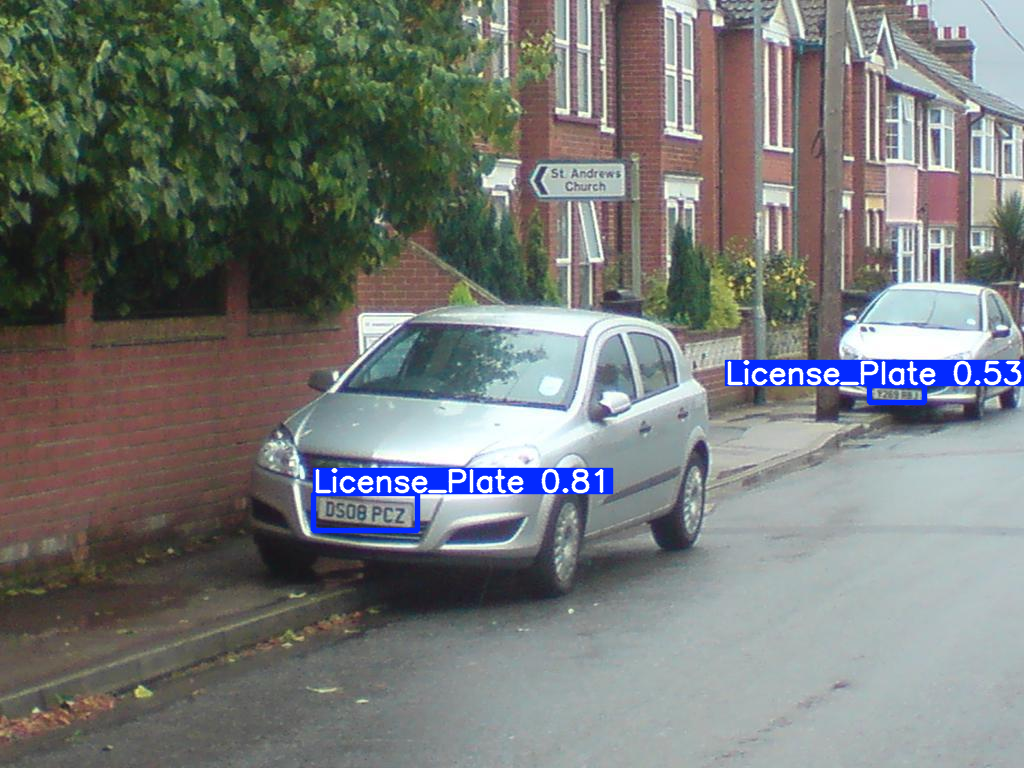


image 1/1 /mnt/c/Users/samul/PycharmProjects/NeuralNetworksProj/projects/licenseplatedetector/../../projects/datasets/licenseplate/test/images/000812dcf304a8e7_jpg.rf.ba32e6c184b3d974abcced6f7c29af6d.jpg: 576x640 2 License_Plates, 23.4ms
Speed: 3.8ms preprocess, 23.4ms inference, 7.8ms postprocess per image at shape (1, 3, 576, 640)


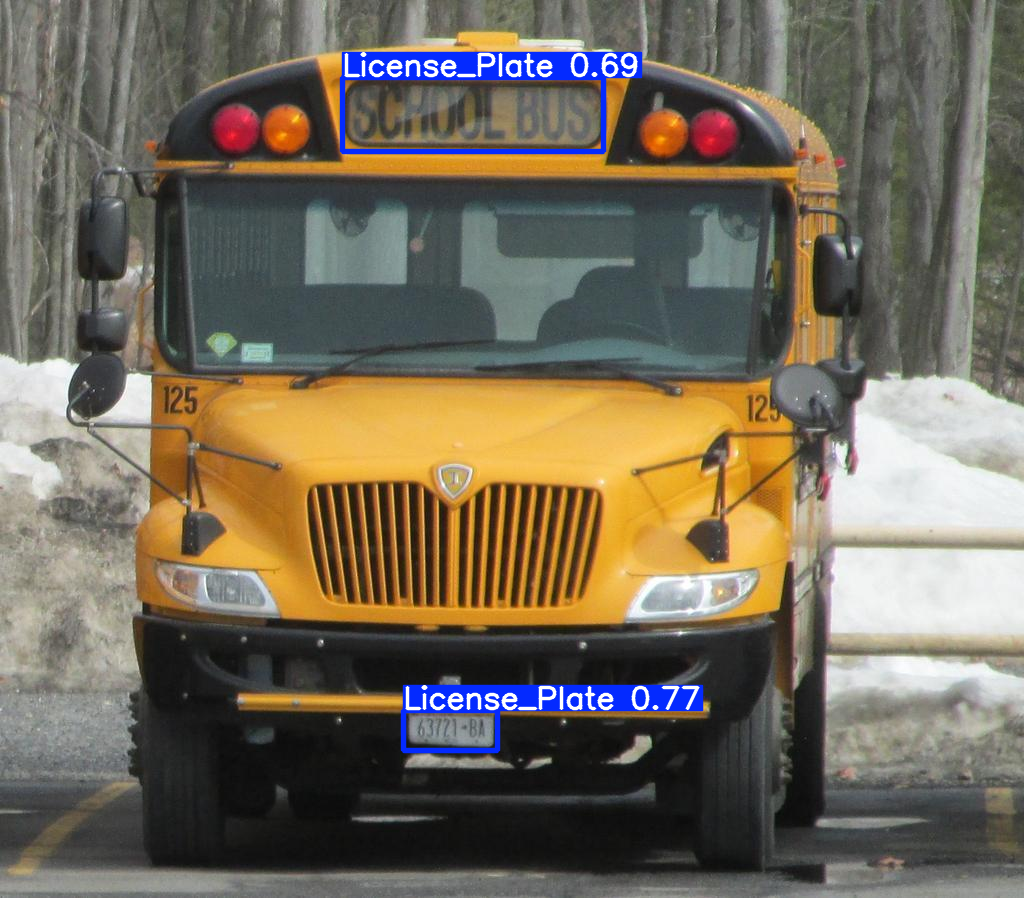


image 1/1 /mnt/c/Users/samul/PycharmProjects/NeuralNetworksProj/projects/licenseplatedetector/../../projects/datasets/licenseplate/test/images/0010f4c10f7ab07e_jpg.rf.1844f6dde3b97ed1c762db933bbacaf3.jpg: 480x640 1 License_Plate, 15.8ms
Speed: 2.1ms preprocess, 15.8ms inference, 3.9ms postprocess per image at shape (1, 3, 480, 640)


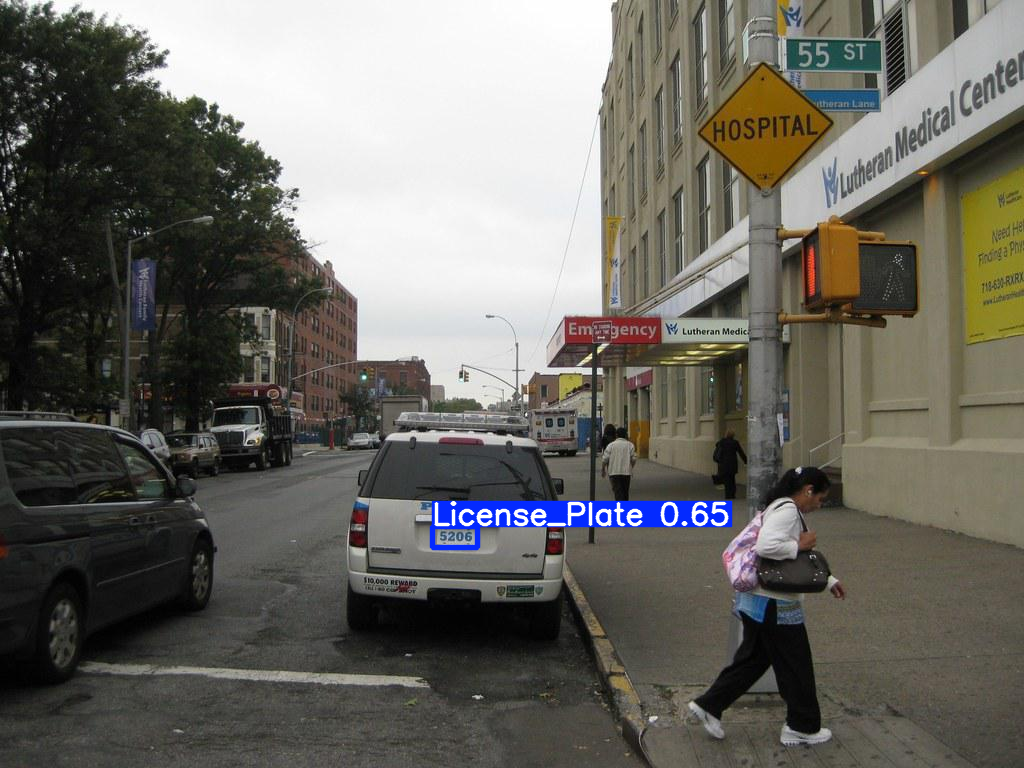

In [20]:
import glob

image_paths = glob.glob("../../projects/datasets/licenseplate/test/images/*.jpg")

# 3 kuvaa
image_paths = image_paths[:3]

for img_path in image_paths:
    # Suoritetaan ennustus ajamalla kuvat mallin läpi
    results = model(img_path)
    for result in results:
        result.show()

Malli osasi paikantaa rekisterikilvet kuvista hyvin. Se kuitenkin sekoitti koulubussin nimikyltin rekisterikilveksi. Tämän luultavasti saisi korjattua koluttamalla mallia useamalla epookilla.

## Datasetin läpikäynti 

Projektissa käytetään Licence Plate Text Recognition datasettiä. Datasetin tekijä on Nick David Yazdan. 

Datasetin sisältö:

Linkki datasettiin: https://www.kaggle.com/datasets/nickyazdani/license-plate-text-recognition-dataset

In [ ]:
import kagglehub

path = kagglehub.dataset_download("nickyazdani/license-plate-text-recognition-dataset")

print("Path to dataset files:", path)

## Datan lataus ja esikäsittely
Projektissa käytetään Licence Plate Text Recognition datasettiä. Datasetin tekijä on Nick David Yazdan.

Datasetin sisältö:

 - 20 000 erilaatuista kuvaa autojen rekisterikilvistä

 - Kuvien laatu vaihtelee huomattavasti, mikä on hyödyllistä mallin kouluttamisessa

 - Datasettiin kuuluu CSV-tiedosto, joka sisältää rekisterinumerot jokaiselle kuvalle

- Datasetissä on 24 puuttuvaa tunnistetta (labelia)

Linkki datasettiin: https://www.kaggle.com/datasets/nickyazdani/license-plate-text-recognition-dataset

In [1]:
import cv2
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from keras.utils import pad_sequences

csv_path = "/home/stefu/.cache/kagglehub/datasets/nickyazdani/license-plate-text-recognition-dataset/versions/1/lpr.csv"
img_dir = "/home/stefu/.cache/kagglehub/datasets/nickyazdani/license-plate-text-recognition-dataset/versions/1/cropped_lps/cropped_lps"

characters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789 -"
char_to_index = {char: idx for idx, char in enumerate(characters)}
index_to_char = {idx: char for char, idx in char_to_index.items()}
num_classes = len(characters) + 1

df = pd.read_csv(csv_path)

2025-05-08 19:29:30.642912: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-08 19:29:30.867457: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746721770.947045   34974 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746721770.968604   34974 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746721771.138853   34974 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Funktio `encode_label(text)` muuntaa rekisterikilven merkkijonon listaksi indeksejä. Näitä tarvitaan, jotta syötemerkkijono voidaan opettaa koneoppimismallille numeerisessa muodossa.

In [2]:
def encode_label(text):
    return [char_to_index[c] for c in text.upper() if c in char_to_index]

Kontrastin venytyksellä parannetaan kuvan kontrastia, mikä auttaa mallia erottamaan piirteet paremmin. Tämä tehdään vähentämällä kuvan pienintä arvoa ja skaalaamalla se 0-255 välille.

In [3]:
def contrast_stretching(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val == min_val:
        return image
    stretched_image = (image - min_val) * (255 / (max_val - min_val))
    return stretched_image.astype(np.uint8)

`preprocess_images` funktio  lukee rekisterikilpikuvia ja niiden vastaavat tekstit annetusta hakemistosta ja CSV-tiedostosta.

Funktion vaiheet:

1. **Kuvien ja labelien lukeminen:**
   Käy läpi CSV-tiedoston rivit ja yrittää avata jokaisen kuvan. Jos kuvaa ei löydy tai sen lukeminen epäonnistuu, kuva ohitetaan.

2. **Kontrastin venytys:**
   Soveltaa `contrast_stretching`-funktiota, joka parantaa kuvan kontrastia skaalaten pikseliarvot välillä 0–255. Tämä tekee rekisterikilven merkeistä erottuvampia.

3. **Uudelleenkokoaminen ja normalisointi:**
   Kuva skaalataan kokoon 128×96 pikseliä ja normalisoidaan välillä 0–1. Tämä helpottaa mallin oppimista ja varmistaa, että kaikki kuvat ovat saman kokoisia.

4. **Yksikanavainen muoto:**
   Kuvan muoto muutetaan (lisätään kanavadimensio), jotta se sopii syötettäväksi konvoluutioverkkoon (CNN).

5. **Labelien koodaus:**
   Rekisterikilven tekstimuotoinen label muunnetaan numeeriseksi listaksi `encode_label`-funktion avulla. Lisäksi tallennetaan myös merkkijonon pituus.

6. **Lopuksi:**
   Palauttaa esikäsitellyt kuvat (`images`), koodatut labelit (`labels`) ja niiden pituudet (`label_lengths`). Jos yhtään kuvaa ei onnistu käsittelemään, ohjelma pysäytetään.

Funktio tulostaa lopuksi myös montako kuvaa onnistuttiin käsittelemään.

In [4]:
def preprocess_images(img_dir):
    images, labels, label_lengths = [], [], []
    skipped_count = 0
    success_count = 0
    for idx, row in df.iterrows():
        try:
            img_path = os.path.join(img_dir, row["images"])
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                skipped_count += 1
                continue

            img = contrast_stretching(img)
            img = cv2.resize(img, (128, 96), interpolation=cv2.INTER_CUBIC)

            if np.max(img) != np.min(img):
                img = (img - np.min(img)) / (np.max(img) - np.min(img))

            img = (img * 255).astype(np.uint8)
            img = np.expand_dims(img, axis=-1)
            images.append(img)
            encoded = encode_label(row["labels"])
            labels.append(encoded)
            label_lengths.append(len(encoded))
            success_count += 1

        except Exception as e:
            print(f"Virhe käsiteltäessä kuvaa {row['images']}: {str(e)}")

    if not images:
        exit(1)

    print(f"Kuvia käsitelty onnistuneesti: {success_count}")
    return images, labels, label_lengths

Esikäsitellyt kuvat ja etiketit valmistellaan mallin syötteiksi. Ensin kuvat ja etiketit luodaan `preprocess_images`-funktion avulla. Tämän jälkeen etiketit täydennetään tasapituiksi pad_sequences-funktiolla, jolloin lyhyemmät etiketit täytetään arvolla -1. Lopuksi kuvat ja täydennetyt etiketit muunnetaan NumPy-taulukoiksi `X ja y`, ja etiketin pituudet tallennetaan erikseen taulukkoon `label_lengths`.

In [5]:
images, labels, label_lengths = preprocess_images(img_dir)

max_label_len = max(label_lengths)
padded_labels = pad_sequences(labels, maxlen=max_label_len, value=-1, padding="post")

X = np.array(images)
y = np.array(padded_labels)
label_lengths = np.array(label_lengths)

Kuvia käsitelty onnistuneesti: 20001


Jaetaan dataset kolmeen osaan: koulutus-, validointi- ja testisetteihin. Koulutussettiä käytetään mallin kouluttamiseen, validointisettiä mallin optimointiin ja testisettiä lopulliseen arviointiin. Datasetin jako tehdään `train_test_split`-funktiolla, joka jakaa datasetin satunnaisesti. Vaikka datasetin jako tehdään satunnaisesti, käytetään samaa satunnaislukua `random_state=1234` toistettavuuden varmistamiseksi.

In [6]:
X_temp, X_test, y_temp, y_test, len_temp, len_test = train_test_split(
    X, y, label_lengths, test_size=0.15, random_state=1234
)

X_train, X_val, y_train, y_val, len_train, len_val = train_test_split(
    X_temp, y_temp, len_temp, test_size=0.1765, random_state=1234
)

Tässä määritetään sekvenssien pituus `time_steps` CTC-häviötä varten, joka riippuu mallin tuottamien aikasteppien määrästä tässä arvoksi saadaan `96 // 8 = 12`, joka perustuu oletettuun alasampalointiin mallin sisällä. Tämän jälkeen luodaan kolme NumPy-taulukkoa `train_input_len,` `val_input_len,` `test_input_len`, jotka sisältävät jokaiselle syötteelle saman pituusarvon — eli kuinka monta aika-askelta malli tuottaa. Näitä arvoja tarvitaan CTC-häviöfunktion syötteeksi mallia koulutettaessa.

In [7]:
time_steps = 96 // 8

train_input_len = np.full((len(X_train), 1), time_steps, dtype=np.int32)
val_input_len = np.full((len(X_val), 1), time_steps, dtype=np.int32)
test_input_len = np.full((len(X_test), 1), time_steps, dtype=np.int32)

## Mallin arkkitehtuuri 

OCR-malli perustuu hybridiin CNN-LSTM-arkkitehtuuriin, joka yhdistää konvoluutioverkkojen ja sekvenssien käsittelyyn soveltuvien LSTM-kerrosten vahvuudet.

Piirteiden erottelu (Feature Extraction)
Mallin alkuosassa on useita konvoluutio- (CNN) kerroksia, joita seuraavat batch-normalisointi ja max pooling -kerrokset.
Näiden avulla erotetaan visuaaliset piirteet rekisterikilpien kuvista tehokkaasti.

Sekvenssin käsittely (Sequence Processing)
CNN-kerrosten tuottamat piirteet muunnetaan sekvenssimuotoon.
Kaksisuuntaiset LSTM-kerrokset (Bidirectional LSTM) käsittelevät sekvenssejä ja tallentavat kontekstuaalista tietoa merkkien väliltä.

Lähtökerros (Output Layer)
Dense-kerros, jossa on softmax-aktivaatio, luokittelee merkit jokaiselle aikavaiheelle.
Jokainen aikavaihe tuottaa todennäköisyysjakauman mahdollisista merkeistä.

In [8]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Reshape, Dense, Dropout, BatchNormalization, Activation
from keras.layers import Bidirectional, LSTM
from keras.layers import Lambda
from keras.layers import RandomFlip, RandomRotation, RandomZoom
from keras._tf_keras.keras.callbacks import EarlyStopping
import os
import tensorflow as tf

os.environ["KERAS_BACKEND"] = "tensorflow"

# Määritellään tärkeät parametrit
img_height, img_width, img_channels = 96, 128, 1
num_classes = 36 + 1  # 26 kirjainta + 10 numeroa + CTC-blank

# Syötekuva
input_img = Input(shape=(img_height, img_width, img_channels), name='image_input')
x = RandomFlip("horizontal")(input_img)
x = RandomRotation(0.05)(x)
x = RandomZoom(0.1)(x)

x = Conv2D(64, (5, 5), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

x = Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

x = Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

x = Conv2D(512, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Conv2D(512, (3, 3), padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

# Muodosta sekvenssi aikadimensiossa (width)
# Muoto: (batch, height, width, channels) → (batch, width, height × channels)
new_shape = (x.shape[2], x.shape[1] * x.shape[3])  # (W, H*C)
x = Reshape(target_shape=new_shape)(x)

x = Bidirectional(LSTM(256, return_sequences=True))(x)
x = Dropout(0.25)(x)
x = Bidirectional(LSTM(256, return_sequences=True))(x)

x = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=input_img, outputs=x)
model.summary()

I0000 00:00:1746721782.254619   34974 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9517 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 96, 128, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 96, 128, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 96, 128, 1)     │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 96, 128, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 128, 64)    │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 128, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 96, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 12, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 16, 512)    │             

 Total params: 18,619,685 (71.03 MB)

 Trainable params: 18,616,741 (71.02 MB)

 Non-trainable params: 2,944 (11.50 KB)

## Datan Valmistelu 

    Kuvat ja tunnisteet ladataan datasetistä

    Dataset jaetaan koulutus- (80%) ja validointisetteihin (20%) 

    Tunnisteet täydennetään yhtenäiseen pituuteen eräkäsittelyä varten 
    
    CTC (Connectionist Temporal Classification) -menetelmää käytetään vaihtuvanpituisten sekvenssien käsittelyyn

In [9]:
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau

labels = Input(name='label', shape=(None,), dtype='int32')
input_length = Input(name='input_length', shape=(1,), dtype='int32')
label_length = Input(name='label_length', shape=(1,), dtype='int32')

def ctc_lambda_func(args):
    y_pred, labels, input_length, label_length = args
    return tf.keras.backend.ctc_batch_cost(labels, y_pred, input_length, label_length)

loss_out = Lambda(ctc_lambda_func, output_shape=(1,), name='ctc_loss')(
    [x, labels, input_length, label_length]
)

ctc_model = Model(inputs=[input_img, labels, input_length, label_length], outputs=loss_out)

optimizer = Adam(learning_rate=0.0001)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

ctc_model.compile(
    optimizer=optimizer,
    loss=lambda y_true, y_pred: y_pred
)

# Muotoile data
train_input_len = train_input_len.astype(np.int32)
val_input_len = val_input_len.astype(np.int32)

train_data = {
    'image_input': X_train,
    'label': y_train,
    'input_length': train_input_len,
    'label_length': np.expand_dims(len_train, axis=1)
}
val_data = {
    'image_input': X_val,
    'label': y_val,
    'input_length': val_input_len,
    'label_length': np.expand_dims(len_val, axis=1)
}

## Koulutuksen asetukset 

Häviöfunktio: CTC-häviö 

Optimointi: Adam

Aikainen pysäytys: Validointihäviön seuranta, kärsivällisyys 10 epookkia 
    
Eräkoko: 100 näytettä 

Epookit: 150 (riippuen aikaisesta pysäytyksestä) 

In [10]:
train_dummy_y = np.zeros((len(X_train), 1), dtype=np.float32)
val_dummy_y = np.zeros((len(X_val), 1), dtype=np.float32)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = ctc_model.fit(
    x=train_data,
    y=train_dummy_y,
    validation_data=(val_data, val_dummy_y),
    epochs=150,
    batch_size=100,
    callbacks=[early_stopping],
    verbose=0
)

model.save("trained_license_plate_model.h5")

I0000 00:00:1746721787.519926   35092 cuda_dnn.cc:529] Loaded cuDNN version 90501


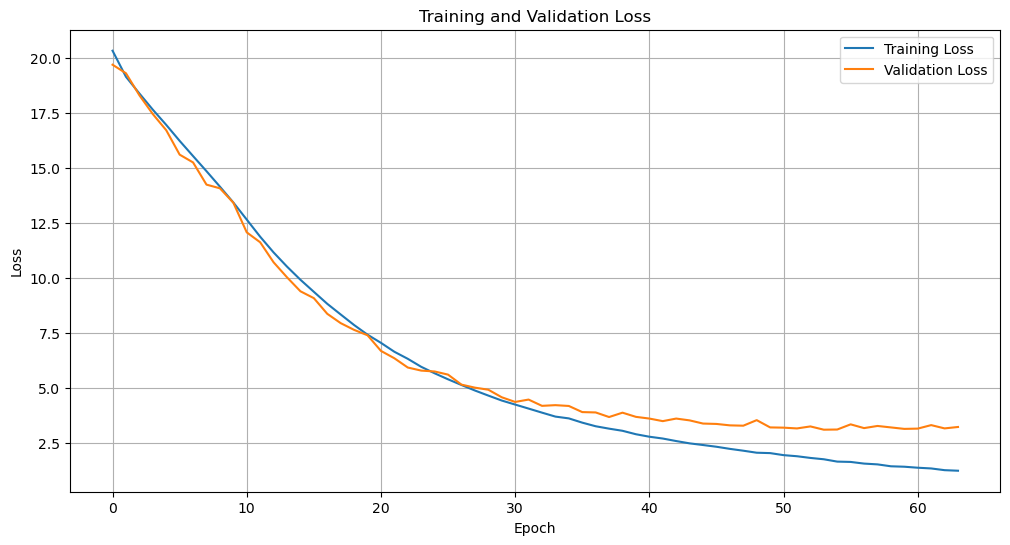

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Mallin evaluointi

Mallin suorituskykyä arvioidaan testisetillä, joka muodostettiin aikaisemmin. Testisetti on 15% alkuperäisestä datasetistä.

Mallin testaamiseen ei kätetä normaalia `model.evaluate()`-funktiota, koska se ei tue CTC-häviötä. Sen sijaan käytetään tulokset tallennetaan `model.predict()`-funktiolla, joka tuottaa ennusteet testikuvista, jotka pitää vielä dekoodata ennen kuin niitä voidaan verrata todellisiin arvoihin.

Koska mallin testaaminen ei tuota suoranaista häviöarvoa, lasketaan ennustetun ja todellisen arvon välinen tarkkuus vertaanalla ennustettua ja todellista arvoa merkkitasolla. Tämä tarkoittaa, että jokainen oikein ennustettu merkki lasketaan oikeaksi, vaikka koko sekvenssi ei olisi oikein.

`preds` muuttuja sisältää mallin ennusteet testikuvista. Ennusteiden tulkintaa varten ne dekoodataan `ctc_decode`-funktion avulla. Tämä funktio muuntaa mallin tuottamat todennäköisyysjakaumat merkkisekvensseiksi. `greedy=False` tarkoittaa, että käytetään beam search -algoritmia ennusteen parantamiseksi. `beam_width=10` määrittää beam searchin leveysarvon, joka vaikuttaa ennusteen tarkkuuteen ja laskentatehoon.

In [16]:
import tensorflow as tf

preds = model.predict(X_test)
decoded, _ = tf.keras.backend.ctc_decode(
    preds,
    input_length=np.ones(preds.shape[0]) * preds.shape[1],
    greedy=False,
    beam_width=10)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


Funktion `decode_sequence(seq)` avulla dekoodataan sekvenssi indekseistä merkkijonoksi. Tämä tehdään käyttämällä `characters`-listaa, joka sisältää kaikki mahdolliset merkit. Funktio käy läpi annetun sekvenssin ja muuntaa sen merkkijonoksi, josta on poistettu kaikki -1 arvot ja indeksit, jotka ylittävät merkkien määrän.

In [17]:
def decode_sequence(seq):
    return ''.join([characters[i] for i in seq if i != -1 and i < len(characters)])

# Tarkkuuden laskeminen
Dekoodatut ennusteet tallennetaan `decoded_sequences`-muuttujaan. Tämän jälkeen käydään läpi kaikki testisetin kuvat ja lasketaan oikeiden merkkien määrä verrattuna todellisiin arvoihin. Oikeat merkit lasketaan yhteen ja tallennetaan `correct_chars`-muuttujaan, kun taas kaikkien merkkien määrä tallennetaan `total_chars`-muuttujaan. Mallin tarkkuus on noin 70%


In [18]:
decoded_sequences = decoded[0].numpy()

correct_chars = 0
total_chars = 0

for i in range(len(X_test)):
    prediction = decode_sequence(decoded_sequences[i])
    true_label = decode_sequence(y_test[i])

    for pred_char, true_char in zip(prediction, true_label):
        if pred_char == true_char:
            correct_chars += 1
    total_chars += len(true_label)

accuracy = correct_chars / total_chars
print(f"\nTest set accuracy: {accuracy:.2%}")


Test set accuracy: 71.48%


# Testikuvien tarkastelu

Plotataan 10 ensimmäistä kuvaa testisetistä, jotta voidaan tarkastella hieman miten malli ennustaa ja millaisia virheitä se mahdollisesti tuottaa. Näytettävistä tuloksista nähdään, että malli saattaa välillä jättää merkin pois tai ennustaa saman muotoista merkkiä virheellisesti (esim. 7 -> T tai A -> 4).

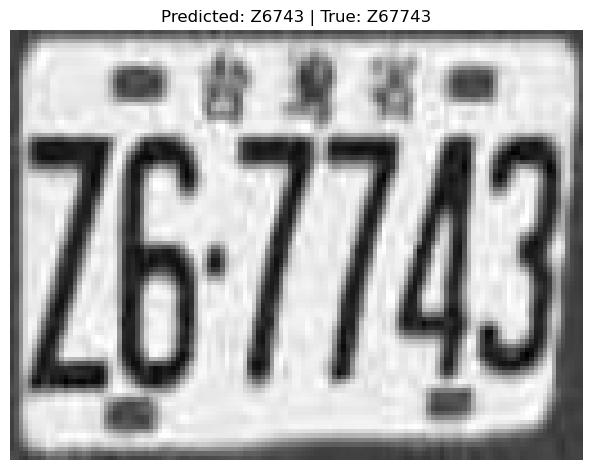

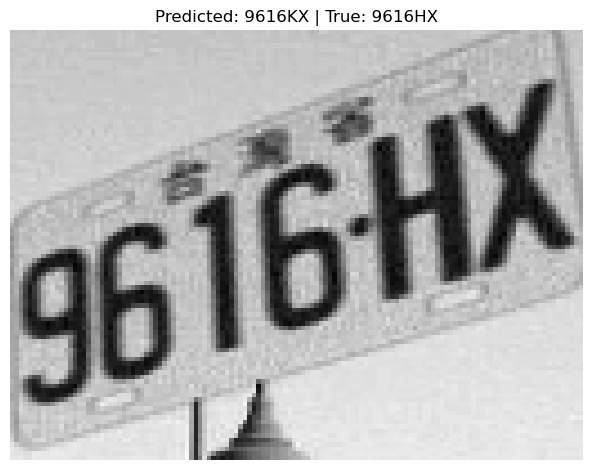

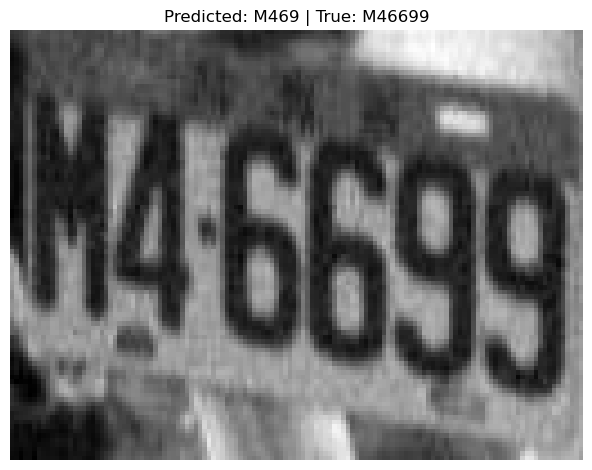

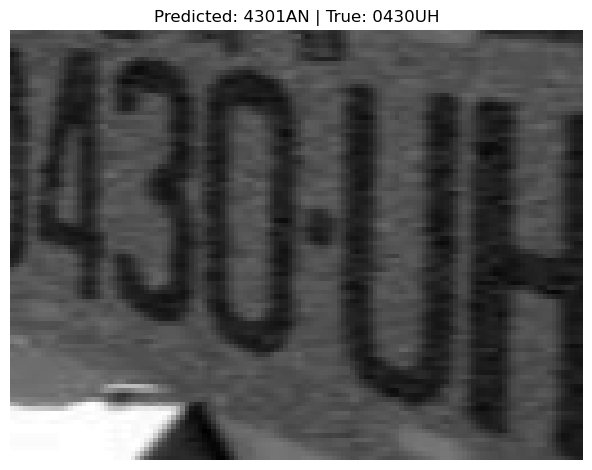

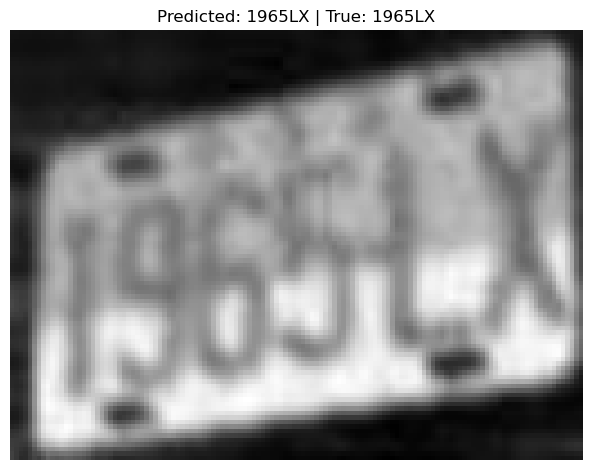

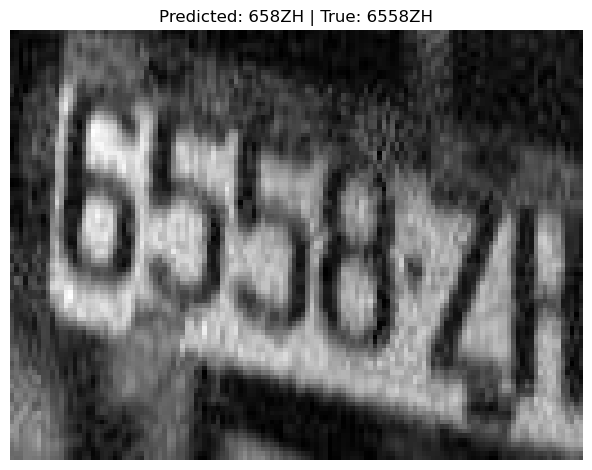

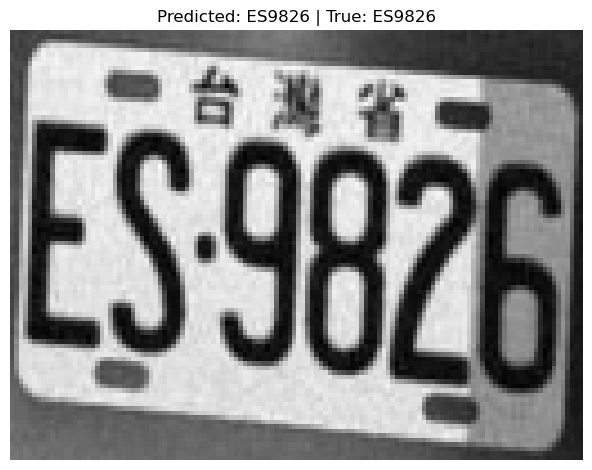

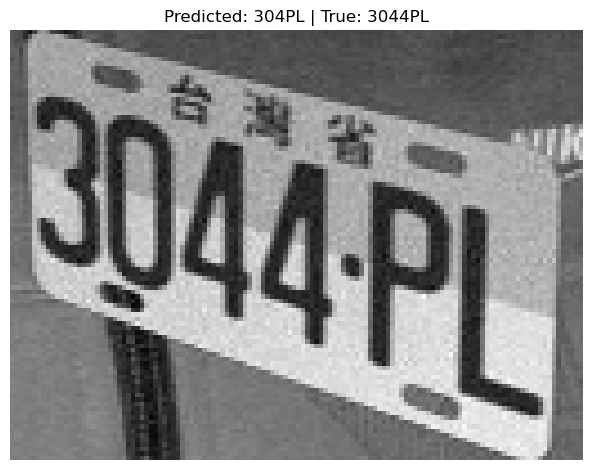

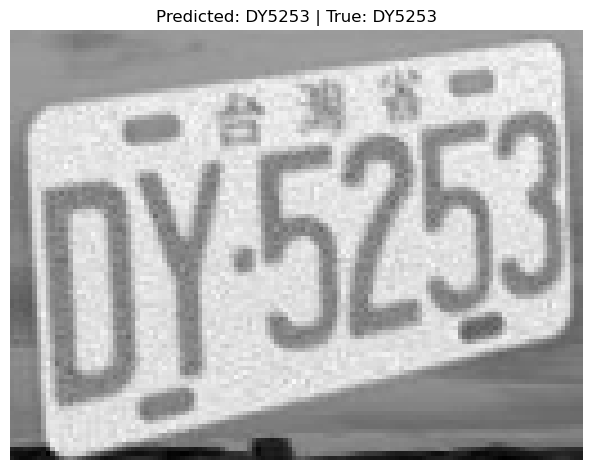

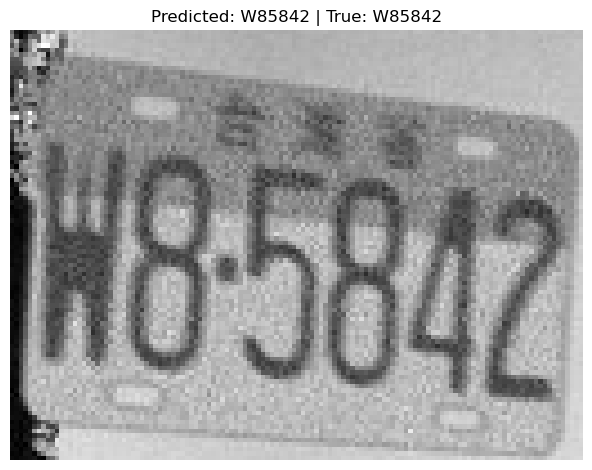

In [23]:
for i in range(10):
    img = X_test[i].squeeze()
    prediction = decode_sequence(decoded_sequences[i])
    true_label = decode_sequence(y_test[i])

    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: {prediction} | True: {true_label}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [20]:
img = "37465.jpg"

def decode_single_sequence(seq):
    return ''.join([characters[int(i)] for i in seq if i != -1 and i < len(characters)])

def preprocess_single_image(image_path):
    try:
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise ValueError("Kuvaa ei voitu lukea.")

        min_val, max_val = np.min(img), np.max(img)
        if max_val != min_val:
            img = (img - min_val) * (255 / (max_val - min_val))
            img = img.astype(np.uint8)

        img = cv2.resize(img, (128, 96), interpolation=cv2.INTER_CUBIC)

        if np.max(img) != np.min(img):
            img = (img - np.min(img)) / (np.max(img) - np.min(img))

        img = (img * 255).astype(np.uint8)
        img = np.expand_dims(img, axis=-1)

        return img

    except Exception as e:
        print(f"Virhe kuvan käsittelyssä ({image_path}): {e}")
        return None


processed_img = preprocess_single_image(img)
input_tensor = np.expand_dims(processed_img, axis=0)
pred = model.predict(input_tensor)

decoded_image, _ = tf.keras.backend.ctc_decode(
    pred,
    input_length=np.ones(pred.shape[0]) * pred.shape[1],
    greedy=False,
    beam_width=10)

decoded_sequence = decoded_image[0].numpy()
image = processed_img.squeeze()
prediction = decode_single_sequence(decoded_sequence[0].flatten())
print(f"Image:")
print(f"  Prediction   : {prediction}")

plt.imshow(image, cmap='gray')
plt.title(f"P: {prediction}")
plt.axis('off')
plt.tight_layout()
plt.show()

Virhe kuvan käsittelyssä (37465.jpg): Kuvaa ei voitu lukea.


[ WARN:0@2242.685] global loadsave.cpp:268 findDecoder imread_('37465.jpg'): can't open/read file: check file path/integrity


ValueError: Invalid dtype: object